# DSMarket - preparacionn dataset por el modeling

## 1. Importing libraries

In [1]:

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import gc
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split # Added this import

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit

from prophet import Prophet

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

Mounted at /content/drive


Analisis de laos datos
---

In [2]:
output_path = "/content/drive/MyDrive/Master/TFM/item_sales_weekly_result.csv"

In [3]:

df = pd.read_csv(output_path)


In [4]:
df.head()

,yearweek,region,category,store_code,item,id,Total_Sales_Weekly,event,sell_price
0,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_001,ACCESORIES_1_001_NYC_1,0,NaN,NaN
1,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_002,ACCESORIES_1_002_NYC_1,0,NaN,NaN
2,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_003,ACCESORIES_1_003_NYC_1,0,NaN,NaN
3,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_004,ACCESORIES_1_004_NYC_1,0,NaN,NaN
4,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_005,ACCESORIES_1_005_NYC_1,0,NaN,NaN


In [5]:
df = df.rename(columns={'Total_Sales_Weekly': 'sales'})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8323770 entries, 0 to 8323769
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   yearweek    int64  
 1   region      object 
 2   category    object 
 3   store_code  object 
 4   item        object 
 5   id          object 
 6   sales       int64  
 7   event       object 
 8   sell_price  float64
dtypes: float64(1), int64(2), object(6)
memory usage: 571.5+ MB


In [7]:
#transformation yearweek de int64 a int32
df["yearweek"]=df["yearweek"].astype("int32")
df["sales"]=df["sales"].astype("int32")

In [8]:
df['year'] = df['yearweek'] // 100
df['week'] = df['yearweek'] % 100

In [9]:
#creaccion de la columna date con incio Sabado
df['yearweek'] = df['yearweek'].astype(str)

df['fecha_semana'] = pd.to_datetime(df['yearweek'] + '-1', format='%G%V-%u')
df['sabado_inicio'] = df['fecha_semana'] - pd.to_timedelta((df['fecha_semana'].dt.weekday - 5) % 7, 'D')
df = df.sort_values('sabado_inicio')


In [10]:
df["date"]=df["sabado_inicio"].astype("datetime64[ns]")

In [11]:
df.drop(columns=["fecha_semana","sabado_inicio"], inplace=True)

In [12]:
df = df[['date'] + list(df.columns.drop('date'))]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8323770 entries, 0 to 8323769
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   date        datetime64[ns]
 1   yearweek    object        
 2   region      object        
 3   category    object        
 4   store_code  object        
 5   item        object        
 6   id          object        
 7   sales       int32         
 8   event       object        
 9   sell_price  float64       
 10  year        int32         
 11  week        int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(7)
memory usage: 730.3+ MB


In [14]:
df.shape

(8323770, 12)

In [15]:
weekly_sales = df.groupby('date')['sales'].sum()
last_50_weeks_sales = weekly_sales.tail(100)
display(last_50_weeks_sales)

,sales
date,
2014-05-24,226260
2014-05-31,266974
2014-06-07,269617
2014-06-14,259608
2014-06-21,240934
2014-06-28,274819
2014-07-05,273001
2014-07-12,265357
2014-07-19,245444


In [16]:
df.describe()

,date,sales,sell_price,year,week
count,8323770,"8,323,770.00","6,575,307.00","8,323,770.00","8,323,770.00"
mean,2013-09-07 10:27:41.538464256,7.89,5.51,"2,013.22",25.76
min,2011-01-29 00:00:00,0.00,0.01,"2,011.00",1.00
25%,2012-05-19 00:00:00,0.00,2.62,"2,012.00",13.00
50%,2013-09-07 00:00:00,2.00,4.20,"2,013.00",25.00
75%,2014-12-27 00:00:00,7.00,7.18,"2,015.00",39.00
max,2016-04-23 00:00:00,"3,539.00",134.15,"2,016.00",52.00
std,NaN,23.75,4.38,1.54,15.04


In [17]:
#pd_sales total ventas = 65695409
df["sales"].sum()

np.int64(65695409)

In [18]:
#comproccion weekly df en termino de ventas
tot_daily_sale=65695409
tot_weekly_sales=65695409
comp= tot_daily_sale - tot_weekly_sales
comp

0

### 1. analisise de los nulos

In [19]:
df.isnull().sum()

,0
date,0
yearweek,0
region,0
category,0
store_code,0
item,0
id,0
sales,0
event,7531030
sell_price,1748463


In [20]:
df["sales"].unique()

array([  0,   8,  22, ..., 934, 920, 783], dtype=int32)

In [21]:
df["sell_price"].unique()

array([    nan,  8.725 ,  2.4625, ...,  8.5519, 34.5268,  1.125 ])

In [22]:
ptsales= df.pivot_table(index="yearweek", columns="id", values = "sales", aggfunc= np.sum).replace(0,np.nan)

<Axes: xlabel='id', ylabel='yearweek'>

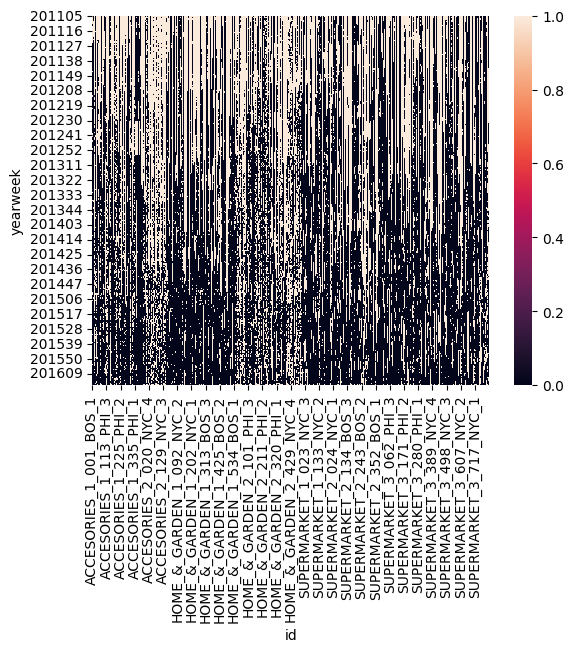

In [23]:
sns.heatmap(ptsales.isnull())

In [24]:
ptprice= df.pivot_table(index="yearweek", columns="id", values = "sell_price", aggfunc= np.sum).replace(0, np.nan)

<Axes: xlabel='id', ylabel='yearweek'>

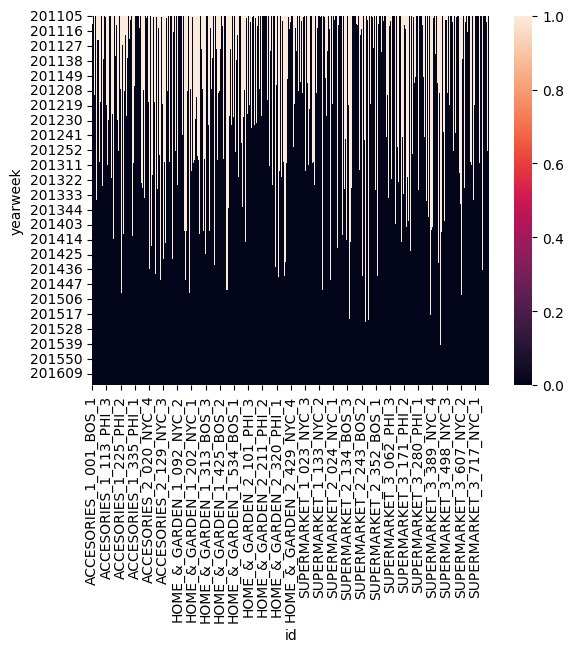

In [25]:
sns.heatmap(ptprice.isnull())

In [26]:
#dado que al inicio, hay mucho precios nulos, vamos a quedarnos con las ultimas 110 semana

In [27]:

all_yearweeks = sorted(df['yearweek'].unique())
cutoff_yearweek = all_yearweeks[-110]

df = df[df['yearweek'] >= cutoff_yearweek].copy()


semanas_por_id = df.groupby('id').size()





In [28]:
#eliminamos la ultimas semana porque no es completa
df = df[df['date'] != '2016-04-23']

In [29]:
df

,date,yearweek,region,category,store_code,item,id,sales,event,sell_price,year,week
6540446,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_208,ACCESORIES_1_208_BOS_2,0,NaN,4.31,2014,12
6540485,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_248,ACCESORIES_1_248_BOS_2,1,NaN,1.25,2014,12
6540359,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_119,ACCESORIES_1_119_BOS_2,1,NaN,2.17,2014,12
6540360,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_120,ACCESORIES_1_120_BOS_2,0,NaN,13.09,2014,12
6540361,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_121,ACCESORIES_1_121_BOS_2,0,NaN,1.33,2014,12
...,...,...,...,...,...,...,...,...,...,...,...,...
8163522,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_236,ACCESORIES_1_236_BOS_3,0,NaN,15.80,2016,16
8163521,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_235,ACCESORIES_1_235_BOS_3,2,NaN,17.26,2016,16
8163497,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_210,ACCESORIES_1_210_BOS_3,0,NaN,7.28,2016,16
8163626,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_341,ACCESORIES_1_341_BOS_3,16,NaN,0.64,2016,16


Analisis de las series temporales

In [30]:
df.shape

(3323410, 12)

In [31]:
min(df["date"])

Timestamp('2014-03-15 00:00:00')

In [32]:
max(df["date"])

Timestamp('2016-04-16 00:00:00')

In [33]:
df["store_code"].nunique()

10

In [34]:
df["event"]=df["event"].fillna("None")

In [35]:
df["yearweek"].nunique()

109

In [36]:
df["date"].nunique()

109

In [37]:
#numero de Serie temporales
df["id"].nunique()

30490

In [38]:
df["category"].nunique()

3

In [39]:
df["date"].unique()


<DatetimeArray>
['2014-03-15 00:00:00', '2014-03-22 00:00:00', '2014-03-29 00:00:00',
 '2014-04-05 00:00:00', '2014-04-12 00:00:00', '2014-04-19 00:00:00',
 '2014-04-26 00:00:00', '2014-05-03 00:00:00', '2014-05-10 00:00:00',
 '2014-05-17 00:00:00',
 ...
 '2016-02-13 00:00:00', '2016-02-20 00:00:00', '2016-02-27 00:00:00',
 '2016-03-05 00:00:00', '2016-03-12 00:00:00', '2016-03-19 00:00:00',
 '2016-03-26 00:00:00', '2016-04-02 00:00:00', '2016-04-09 00:00:00',
 '2016-04-16 00:00:00']
Length: 109, dtype: datetime64[ns]

In [40]:
df["date"].unique().shape

(109,)

In [42]:
# ver si la TS estan completas
assert (df["id"].nunique() *109)== df.shape[0], "las ts no son completas"

Analisis del target y precios

<Axes: ylabel='sales'>

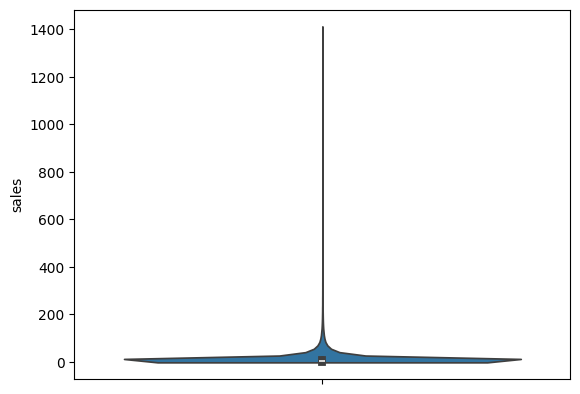

In [69]:
sns.violinplot(y=df["sales"])


<Axes: ylabel='sell_price'>

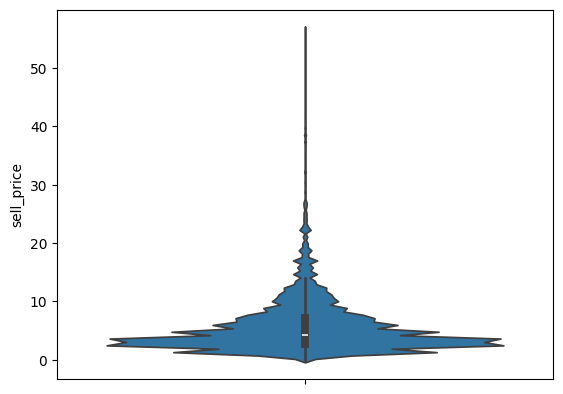

In [58]:
sns.violinplot(y=df["sell_price"])

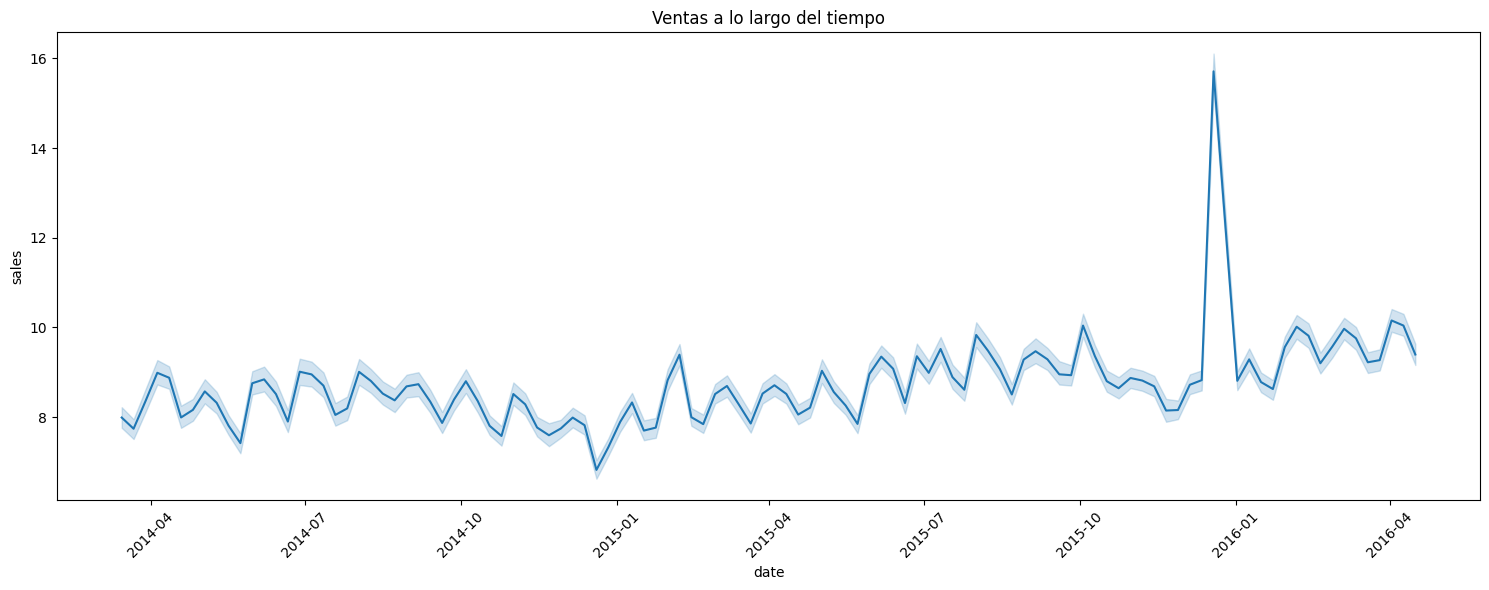

In [67]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df, x="date", y="sales")
plt.xticks(rotation=45)
plt.title("Ventas a lo largo del tiempo")
plt.tight_layout()

plt.show()

preparacion de los datos apartir de una muestra
---

transformation del dataset imputar nulos de price

In [ ]:
# para no romper las serie temporales utilizamos las funciones backforward and forward para remplazar los precios nulos
 df["sell_price"]= (
    df
    .groupby(["id"])
    ["sell_price"]
    .transform(
        lambda series: series.bfill().ffill()
    )
)

In [ ]:
df.isnull().sum()

,0
date,0
yearweek,0
region,0
category,0
store_code,0
item,0
id,0
sales,0
event,0
sell_price,0


creation features

In [ ]:
df["revenue"]= df["sales"]*df["sell_price"]

In [ ]:
df["revenue_log"]= np.log(df["revenue"]).replace(-np.inf, 0)

In [ ]:
df["sales_log"] = np.log(df["sales"]).replace(-np.inf, 0)

In [ ]:
def agregar_features_estacionalidad(df):
    """
    Agrega features que capturen patrones estacionales
    """
    print("🔧 Agregando features de estacionalidad...")

    # 1. PROMEDIO HISTÓRICO POR SEMANA DEL AÑO (MUY IMPORTANTE)
    df['sales_avg_by_week_historical'] = (
        df.groupby(['id', 'week'])['sales']
        .transform(lambda x: x.expanding().mean())
    )


    df['sales_avg_by_week_store_category'] = (
        df.groupby(['store_code', 'category', 'week'])['sales']
        .transform(lambda x: x.expanding().mean())
    )

    # 2. MISMO PERÍODO AÑO ANTERIOR (52 semanas atrás)
    df['sales_same_week_last_year'] = (
        df.groupby(['id'])['sales'].shift(52)
    )

    df['sales_ratio_vs_last_year'] = (
        df['sales'] / (df['sales_same_week_last_year'] + 1)
    )

    # 3. ÍNDICE ESTACIONAL
    df['seasonal_index'] = (
        df['sales'] / (df['sales_avg_by_week_historical'] + 1)
    )


    # 7. TENDENCIA ANUAL
    df['sales_yearly_trend'] = (
        df.groupby(['id'])['sales']
        .transform(lambda x: x.rolling(52, min_periods=26).mean())
    )

    # 8. DESVIACIÓN DE LA TENDENCIA
    df['sales_deviation_from_yearly_trend'] = (
        df['sales'] - df['sales_yearly_trend']
    )

    print("✅ Features de estacionalidad agregadas!")
    return df


In [ ]:
agregar_features_estacionalidad(df)

🔧 Agregando features de estacionalidad...
✅ Features de estacionalidad agregadas!


,date,yearweek,region,category,store_code,item,id,sales,event,sell_price,year,week,revenue,revenue_log,sales_log,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend
6540446,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_208,ACCESORIES_1_208_BOS_2,0,None,4.31,2014,12,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,NaN,NaN
6540485,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_248,ACCESORIES_1_248_BOS_2,1,None,1.25,2014,12,1.25,0.22,0.00,1.00,0.50,NaN,NaN,0.50,NaN,NaN
6540359,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_119,ACCESORIES_1_119_BOS_2,1,None,2.17,2014,12,2.17,0.77,0.00,1.00,0.67,NaN,NaN,0.50,NaN,NaN
6540360,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_120,ACCESORIES_1_120_BOS_2,0,None,13.09,2014,12,0.00,0.00,0.00,0.00,0.50,NaN,NaN,0.00,NaN,NaN
6540361,2014-03-15,201412,Boston,ACCESORIES,BOS_2,ACCESORIES_1_121,ACCESORIES_1_121_BOS_2,0,None,1.33,2014,12,0.00,0.00,0.00,0.00,0.40,NaN,NaN,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8163522,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_236,ACCESORIES_1_236_BOS_3,0,None,15.80,2016,16,0.00,0.00,0.00,4.33,4.31,1.00,0.00,0.00,4.23,-4.23
8163521,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_235,ACCESORIES_1_235_BOS_3,2,None,17.26,2016,16,34.53,3.54,0.69,6.00,4.31,11.00,0.17,0.29,4.98,-2.98
8163497,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_210,ACCESORIES_1_210_BOS_3,0,None,7.28,2016,16,0.00,0.00,0.00,1.33,4.31,2.00,0.00,0.00,4.13,-4.13
8163626,2016-04-16,201616,Boston,ACCESORIES,BOS_3,ACCESORIES_1_341,ACCESORIES_1_341_BOS_3,16,None,0.64,2016,16,10.21,2.32,2.77,20.33,4.31,21.00,0.73,0.75,28.85,-12.85


In [ ]:
def build_ts_features(df, gb_list, target, agg_func, frec):


    new_name = "_".join(gb_list + [target] + [agg_func.__name__] + [frec.replace('-', '_')])

    lags = [1, 2, 4, 7]
    windows = [3, 7, 14]

    gbdf = (
        df
        .set_index("date")
        .groupby(gb_list)
        .resample(frec)
        [target]
        .agg(agg_func)
        .reset_index()
    )

    # Features originales
    for i in lags:
        gbdf[f"{new_name}_shift_{i}"] = gbdf.groupby(gb_list)[target].transform(lambda x: x.shift(i))

    for i in windows:
        gbdf[f"{new_name}_ma_{i}"] = gbdf.groupby(gb_list)[target].transform(
            lambda x: x.shift(1).rolling(i, min_periods=1).mean()
        )



    # Tendencia
    gbdf[f"{new_name}_trend_7"] = gbdf.groupby(gb_list)[target].transform(
        lambda x: x.rolling(7, min_periods=2).apply(
            lambda y: np.polyfit(range(len(y)), y, 1)[0] if len(y) > 1 else 0, raw=False
        )
    )

    # Volatilidad
    gbdf[f"{new_name}_std_7"] = gbdf.groupby(gb_list)[target].transform(
        lambda x: x.shift(1).rolling(7, min_periods=1).std()
    )

     # Coeficiente de variación
    gbdf[f"{new_name}_cv_7"] = gbdf.groupby(gb_list)[target].transform(
        lambda x: x.shift(1).rolling(7, min_periods=1).std() / (x.shift(1).rolling(7, min_periods=1).mean() + 1)
    )

    #  Ratio vs semana anterior
    gbdf[f"{new_name}_ratio_shift_1"] = gbdf.groupby(gb_list)[target].transform(
        lambda x: x / (x.shift(1) + 1)
    )

    #  Momentum
    gbdf[f"{new_name}_momentum_7"] = gbdf.groupby(gb_list)[target].transform(
        lambda x: (x.diff() > 0).rolling(7, min_periods=1).sum()
    )

    gbdf.drop(target, axis=1, inplace=True)

    if df["date"].isin(gbdf["date"]).any():
        df = pd.merge(left=df, right=gbdf, how="left", on=["date"] + gb_list)
    else:
        df = pd.merge_asof(
            df.sort_values("date"),
            gbdf.sort_values("date"),
            by=gb_list,
            on="date",
            direction="backward"
        )

    return df


In [ ]:
df= build_ts_features(
    df= df,
    gb_list= ["store_code","category"],
    target= "sales",
    agg_func= np.sum,
    frec= "W-SAT"
    )

In [ ]:
df= build_ts_features(
    df= df,
    gb_list= ["store_code","category"],
    target= "revenue",
    agg_func= np.sum,
    frec= "W-SAT"
    )

In [ ]:
df= build_ts_features(
    df= df,
    gb_list= ["store_code","item"],
    target= "sales",
    agg_func= np.sum,
    frec= "W-SAT"
    )

In [ ]:
def agregar_features_ciclicas(df):

    df = df.copy()

    # Features cíclicas de semana
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

    # Features cíclicas de mes
    df['month'] = df['date'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)



    return df

df = agregar_features_ciclicas(df)

In [ ]:
df.sample(15)

,date,yearweek,region,category,store_code,item,id,sales,event,sell_price,year,week,revenue,revenue_log,sales_log,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos
140241,2014-04-12,201416,New York,HOME_&_GARDEN,NYC_3,HOME_&_GARDEN_2_007,HOME_&_GARDEN_2_007_NYC_3,4,None,3.23,2014,16,12.90,2.56,1.39,4.00,11.35,NaN,NaN,0.80,NaN,NaN,"11,316.00","10,692.00","10,272.00",NaN,"10,690.00","10,585.50","10,585.50",161.00,552.96,0.05,0.92,2.00,"53,001.76","54,200.47","51,132.06",NaN,"52,764.21","52,356.17","52,356.17",-36.63,"1,518.65",0.03,0.94,1.00,4.00,8.00,5.00,NaN,4.67,4.75,4.75,-0.00,2.50,0.43,0.80,1.00,0.94,-0.35,4,0.87,-0.50
400265,2014-06-14,201425,New York,HOME_&_GARDEN,NYC_1,HOME_&_GARDEN_1_394,HOME_&_GARDEN_1_394_NYC_1,3,None,6.10,2014,25,18.30,2.91,1.10,3.00,8.40,NaN,NaN,0.75,NaN,NaN,"6,026.00","6,104.00","5,459.00","5,921.00","5,922.00","5,747.14","5,675.69",94.43,358.09,0.06,1.00,4.00,"31,676.16","32,036.91","28,818.85","31,283.56","31,158.52","30,352.80","29,844.78",467.71,"1,571.24",0.05,1.00,4.00,1.00,5.00,2.00,4.00,2.33,3.71,3.62,-0.57,2.81,0.60,1.50,3.00,0.12,-0.99,6,0.00,-1.00
256635,2014-05-10,201420,Boston,SUPERMARKET,BOS_3,SUPERMARKET_3_128,SUPERMARKET_3_128_BOS_3,0,None,3.58,2014,20,0.00,0.00,0.00,0.00,10.66,NaN,NaN,0.00,NaN,NaN,"17,082.00","16,133.00","18,474.00","14,742.00","16,556.67","16,525.29","16,470.00",36.61,"1,161.54",0.07,0.99,4.00,"51,937.61","47,769.67","57,031.39","43,054.81","49,688.07","49,355.28","48,966.92",297.76,"4,605.60",0.09,0.97,4.00,4.00,2.00,2.00,4.00,3.67,3.43,3.38,-0.43,1.81,0.41,0.00,4.00,0.66,-0.75,5,0.50,-0.87
1829129,2015-05-02,201519,New York,HOME_&_GARDEN,NYC_2,HOME_&_GARDEN_2_473,HOME_&_GARDEN_2_473_NYC_2,1,None,9.96,2015,19,9.96,2.30,0.00,0.50,5.55,0.00,1.00,0.67,1.48,-0.48,"5,488.00","5,779.00","5,897.00","5,925.00","5,520.67","5,789.29","5,574.14",-72.61,297.27,0.05,1.06,4.00,"29,643.62","31,438.85","30,775.05","30,269.08","30,250.77","30,752.47","29,363.18",-256.90,918.32,0.03,1.03,3.00,1.00,0.00,3.00,2.00,0.67,1.29,1.86,-0.14,1.11,0.49,0.50,2.00,0.75,-0.66,5,0.50,-0.87
2204540,2015-08-01,201532,New York,ACCESORIES,NYC_4,ACCESORIES_1_056,ACCESORIES_1_056_NYC_4,0,None,1.25,2015,32,0.00,0.00,0.00,0.00,3.96,0.00,0.00,0.00,0.44,-0.44,"2,482.00","2,615.00","2,723.00","2,722.00","2,613.67","2

Transformacion of the object

In [ ]:

def optimize_dtypes(df):
    for col in ['yearweek', 'region', 'category', 'store_code', 'item', 'id', 'event']:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # Convertir float64 a float32 para ahorar RAM
    float_cols = df.select_dtypes(include=['float64']).columns
    for col in float_cols:
        df[col] = df[col].astype('float32')

    return df

df = optimize_dtypes(df)

In [ ]:
# One-Hot Encoding
columns_to_encode = ['region', 'category', 'event']
existing_columns_to_encode = [col for col in columns_to_encode if col in df.columns]


if existing_columns_to_encode:
    df = pd.get_dummies(df, columns=existing_columns_to_encode)


le_store = LabelEncoder()
df['store_code_encoded'] = le_store.fit_transform(df['store_code'].astype(str)).astype('int16')

id_target = df.groupby('id')['sales'].mean()
df['id_encoded'] = df['id'].map(id_target)
id
item_target = df.groupby('item')['sales'].mean()
df['item_encoded'] = df['item'].map(item_target)

print(f"✅ Features adicionales creadas")
print(f"Total columnas: {len(df.columns)}")

✅ Features adicionales creadas
Total columnas: 75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323410 entries, 0 to 3323409
Data columns (total 75 columns):
 #   Column                                               Dtype         
---  ------                                               -----         
 0   date                                                 datetime64[ns]
 1   yearweek                                             category      
 2   store_code                                           category      
 3   item                                                 category      
 4   id                                                   category      
 5   sales                                                int32         
 6   sell_price                                           float32       
 7   year                                                 int32         
 8   week                                                 int32         
 9   revenue                                              float32       
 10  revenu

In [ ]:
# transformacion a int yearweek
df["yearweek"] = df["yearweek"].astype(str).astype("int32")

In [ ]:
df["date"].unique()

<DatetimeArray>
['2014-03-15 00:00:00', '2014-03-22 00:00:00', '2014-03-29 00:00:00',
 '2014-04-05 00:00:00', '2014-04-12 00:00:00', '2014-04-19 00:00:00',
 '2014-04-26 00:00:00', '2014-05-03 00:00:00', '2014-05-10 00:00:00',
 '2014-05-17 00:00:00',
 ...
 '2016-02-13 00:00:00', '2016-02-20 00:00:00', '2016-02-27 00:00:00',
 '2016-03-05 00:00:00', '2016-03-12 00:00:00', '2016-03-19 00:00:00',
 '2016-03-26 00:00:00', '2016-04-02 00:00:00', '2016-04-09 00:00:00',
 '2016-04-16 00:00:00']
Length: 109, dtype: datetime64[ns]

Creaccion de los dataset para el modelo

In [ ]:
target_to_exc= ["sales_log", "sales","revenue","revenue_log"]

In [ ]:
cat_cols = []

for col in df.columns:
    if df[col].dtype == 'category':
        cat_cols.append(col)

print("Columnas dtype object:", cat_cols)

Columnas dtype object: ['store_code', 'item', 'id']


In [ ]:
all_dates = sorted(df["date"].unique())

In [ ]:
max(df["date"])

Timestamp('2016-04-16 00:00:00')

In [ ]:
df["date"].unique()

<DatetimeArray>
['2014-03-15 00:00:00', '2014-03-22 00:00:00', '2014-03-29 00:00:00',
 '2014-04-05 00:00:00', '2014-04-12 00:00:00', '2014-04-19 00:00:00',
 '2014-04-26 00:00:00', '2014-05-03 00:00:00', '2014-05-10 00:00:00',
 '2014-05-17 00:00:00',
 ...
 '2016-02-13 00:00:00', '2016-02-20 00:00:00', '2016-02-27 00:00:00',
 '2016-03-05 00:00:00', '2016-03-12 00:00:00', '2016-03-19 00:00:00',
 '2016-03-26 00:00:00', '2016-04-02 00:00:00', '2016-04-09 00:00:00',
 '2016-04-16 00:00:00']
Length: 109, dtype: datetime64[ns]

In [ ]:
min(df["date"])

Timestamp('2014-03-15 00:00:00')

In [ ]:
train_dates = all_dates[:-50]
test_dates = all_dates[-50:-15]
validation_dates = all_dates[-15:-4]
prediction_dates = all_dates[-4:]

In [ ]:
def get_data_splits(df, split_dates):
    X_ = (
        df[df["date"].isin(split_dates)]
        .drop(
         ['date'] + cat_cols + target_to_exc, axis = 1)
    .set_index("id_encoded"))


    y_ = df[df["date"].isin(split_dates)].set_index("id_encoded")["sales"]

    print(split_dates)
    print(X_.shape, y_.shape)

    return X_, y_

X_train, y_train = get_data_splits(df=df, split_dates=train_dates)
X_test, y_test = get_data_splits(df=df, split_dates=test_dates)
X_val, y_val = get_data_splits(df=df, split_dates=validation_dates)
X_pred, y_pred = get_data_splits(df=df, split_dates=prediction_dates)

[Timestamp('2014-03-15 00:00:00'), Timestamp('2014-03-22 00:00:00'), Timestamp('2014-03-29 00:00:00'), Timestamp('2014-04-05 00:00:00'), Timestamp('2014-04-12 00:00:00'), Timestamp('2014-04-19 00:00:00'), Timestamp('2014-04-26 00:00:00'), Timestamp('2014-05-03 00:00:00'), Timestamp('2014-05-10 00:00:00'), Timestamp('2014-05-17 00:00:00'), Timestamp('2014-05-24 00:00:00'), Timestamp('2014-05-31 00:00:00'), Timestamp('2014-06-07 00:00:00'), Timestamp('2014-06-14 00:00:00'), Timestamp('2014-06-21 00:00:00'), Timestamp('2014-06-28 00:00:00'), Timestamp('2014-07-05 00:00:00'), Timestamp('2014-07-12 00:00:00'), Timestamp('2014-07-19 00:00:00'), Timestamp('2014-07-26 00:00:00'), Timestamp('2014-08-02 00:00:00'), Timestamp('2014-08-09 00:00:00'), Timestamp('2014-08-16 00:00:00'), Timestamp('2014-08-23 00:00:00'), Timestamp('2014-08-30 00:00:00'), Timestamp('2014-09-06 00:00:00'), Timestamp('2014-09-13 00:00:00'), Timestamp('2014-09-20 00:00:00'), Timestamp('2014-09-27 00:00:00'), Timestamp('20

In [ ]:
X_pred

,yearweek,sell_price,year,week,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos,region_Boston,region_New York,region_Philadelphia,category_ACCESORIES,category_HOME_&_GARDEN,category_SUPERMARKET,event_Easter,event_NewYear,event_None,event_Ramadan starts,event_SuperBowl,event_Thanksgiving,store_code_encoded,item_encoded
id_encoded,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.80,201613,3.20,2016,13,0.33,2.99,0.00,0.00,0.00,0.83,-0.83,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,0.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,0.63
0.40,201613,2.46,2016,13,0.00,2.98,0.00,0.00,0.00,0.21,-0.21,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,0.00,0.00,0.00,0.00,0.00,0.14,0.14,-0.11,0.38,0.33,0.00,1.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,0.48
1.53,201613,9.84,2016,13,1.67,2.98,1.00,1.00,0.75,1.73,0.27,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,2.00,3.00,3.00,2.00,3.33,2.86,2.29,0.00,1.77,0.46,0.67,2.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,1.92
1.39,201613,4.96,2016,13,2.33,2.98,0.00,4.00,1.20,1.48,2.52,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,1.00,4.00,0.00,4.00,2.00,2.00,1.71,0.25,1.63,0.54,2.00,3.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,2.61
0.33,201613,16.21,2016,13,0.00,2.98,0.00,0.00,0.00,0.02,-0.02,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86",

In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 1798910 entries, 2.091743119266055 to 3.1743119266055047
Series name: sales
Non-Null Count    Dtype
--------------    -----
1798910 non-null  int32
dtypes: int32(1)
memory usage: 20.6 MB


In [ ]:
X_train.sample(3)

,yearweek,sell_price,year,week,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos,region_Boston,region_New York,region_Philadelphia,category_ACCESORIES,category_HOME_&_GARDEN,category_SUPERMARKET,event_Easter,event_NewYear,event_None,event_Ramadan starts,event_SuperBowl,event_Thanksgiving,store_code_encoded,item_encoded
id_encoded,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2.76,201446,4.25,2014,46,1.00,4.75,NaN,NaN,0.50,1.46,-0.46,"11,170.00","11,041.00","11,400.00","11,128.00","11,117.33","11,442.00","11,488.71",-168.89,492.07,0.04,1.00,4.00,"38,325.19","37,392.05","38,259.23","35,427.56","37,656.43","38,147.64","36,871.16",-373.47,"1,825.08",0.05,0.99,4.00,4.00,2.00,2.00,0.00,3.67,2.43,2.57,0.07,1.72,0.50,0.20,4.00,-0.66,0.75,11,-0.50,0.87,False,True,False,False,False,True,False,False,True,False,False,False,6,3.18
6.86,201445,3.90,2014,45,0.00,11.43,NaN,NaN,0.00,8.91,-8.91,"14,658.00","15,256.00","16,229.00","15,550.00","15,462.33","15,717.14","15,943.86",-146.00,672.60,0.04,1.06,3.00,"46,511.69","48,060.42","49,033.69","48,085.56","48,818.32","48,284.36","47,772.05",271.38,"1,961.16",0.04,1.08,4.00,0.00,0.00,1.00,10.00,0.00,5.57,7.71,-2.57,6.80,1.04,0.00,1.00,-0.75,0.66,11,-0.50,0.87,False,False,True,False,False,True,False,False,True,False,False,False,7,9.11
4.54,201512,10.61,2015,12,4.00,6.41,7.00,0.12,0.20,4.19,-3.19,"4,052.00","4,119.00","3,701.00","3,702.00","4,041.00","3,969.43","3,819.86",16.43,224.74,0.06,1.05,4.00,"21,609.92","23,433.74","20,530.17","19,095.97","21,951.04","21,192.18","19,919.72",269.01,"1,310.12",0.06,1.06,4.00,5.00,3.00,8.00,3.00,4.33,4.29,4.14,-0.18,2.21,0.42,0.17,3.00,0.99,0.12,3,1.00,0.00,False,True,False,True,False,False,False,False,True,False,False,False,5,2.90


In [ ]:
y_train.sample(3)

,sales
id_encoded,
4.39,0
0.95,1
26.50,24


Xboost

In [ ]:
pip install catboost

In [ ]:
from catboost import CatBoostRegressor, Pool

In [ ]:
cat_model = CatBoostRegressor(
    iterations=800,               # mucho menos
    learning_rate=0.05,           # un poco más alto para compensar
    depth=6,                      # más rápido, estable
    l2_leaf_reg=5,
    min_data_in_leaf=50,          # ayuda a evitar overfitting + acelera
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,

    # MUCHÍSIMO más rápido
    grow_policy='SymmetricTree',
    bootstrap_type='Bernoulli',
    subsample=0.7,

    # Menos splits → mucho más rápido
    border_count=64,

    # early stopping REAL
    early_stopping_rounds=50,

    verbose=100
)

In [ ]:
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 20.7675923	test: 20.7376210	best: 20.7376210 (0)	total: 77.7ms	remaining: 1m 2s
100:	learn: 4.3808096	test: 4.7549930	best: 4.7549930 (100)	total: 8.4s	remaining: 58.2s
200:	learn: 3.6994725	test: 4.1675026	best: 4.1675026 (200)	total: 15.6s	remaining: 46.4s
300:	learn: 3.3883179	test: 4.0130843	best: 4.0130843 (300)	total: 22.7s	remaining: 37.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.9772657
bestIteration = 343

Shrink model to first 344 iterations.


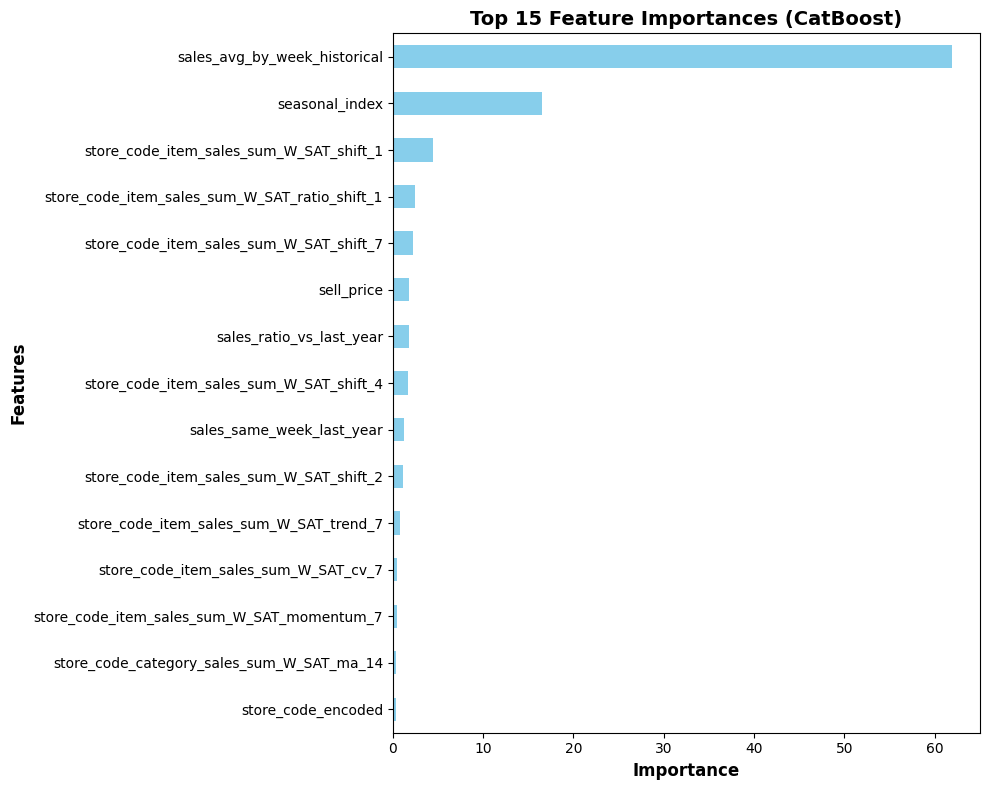

In [ ]:

feature_importances = cat_model.get_feature_importance()

feature_names = X_train.columns

importance_series = pd.Series(feature_importances, index=feature_names)

top_features_to_plot = importance_series.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 8))
top_features_to_plot.sort_values(ascending=True).plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Top 15 Feature Importances (CatBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

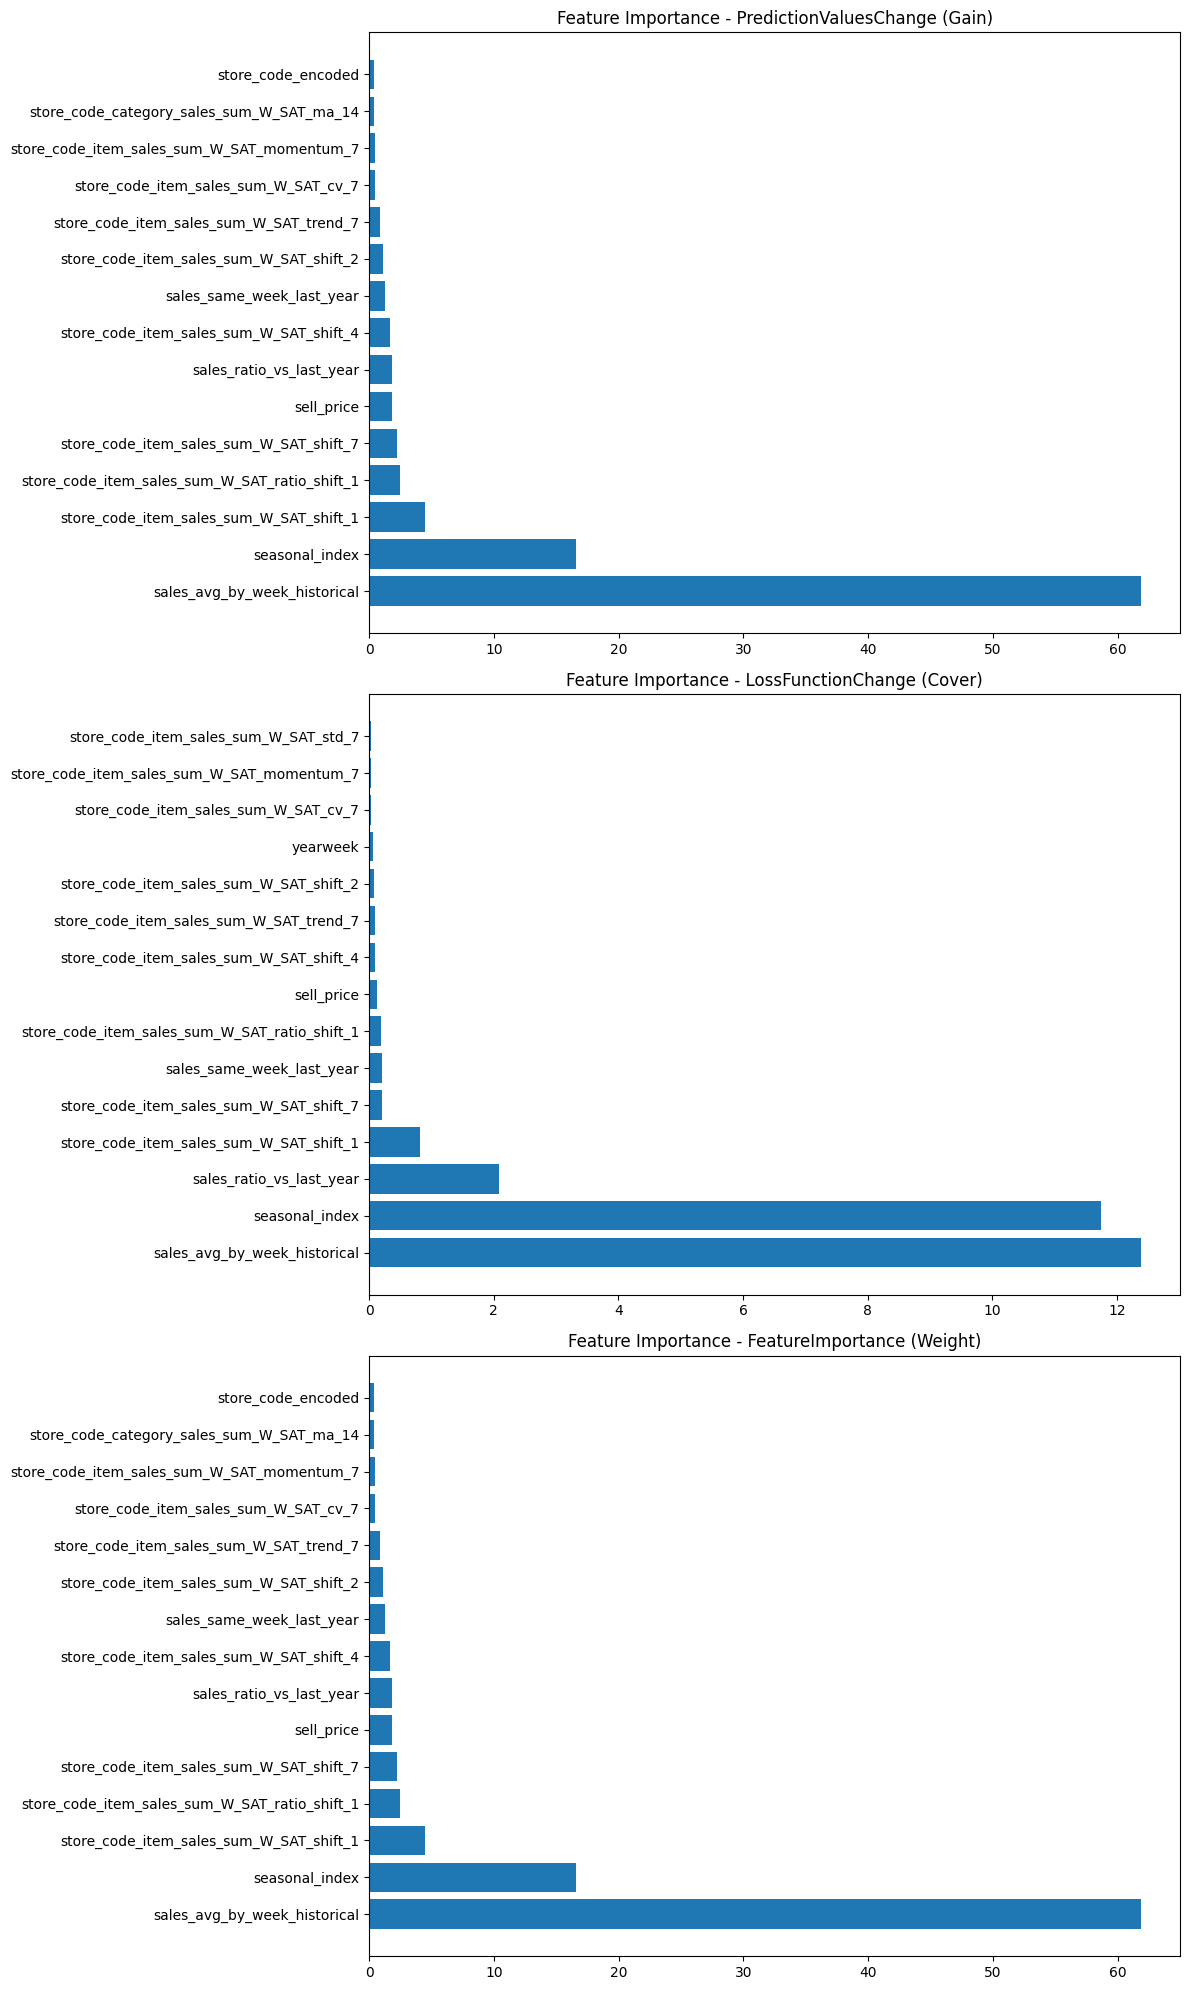

In [ ]:

train_pool = Pool(X_train, y_train)

importance_gain = cat_model.get_feature_importance(data=train_pool, type='PredictionValuesChange')
importance_cover = cat_model.get_feature_importance(data=train_pool, type='LossFunctionChange')
importance_weight = cat_model.get_feature_importance(type='FeatureImportance') # 'FeatureImportance' typically doesn't require data

# Obtener nombres de columnas
feature_names = X_train.columns

# Crear DataFrames para graficar
df_gain = pd.DataFrame({"feature": feature_names, "importance": importance_gain}).sort_values(by="importance", ascending=False).head(15)
df_cover = pd.DataFrame({"feature": feature_names, "importance": importance_cover}).sort_values(by="importance", ascending=False).head(15)
df_weight = pd.DataFrame({"feature": feature_names, "importance": importance_weight}).sort_values(by="importance", ascending=False).head(15)

# Graficar
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Plotting top 15 features for each type
axes[0].barh(df_gain['feature'], df_gain['importance'])
axes[0].set_title("Feature Importance - PredictionValuesChange (Gain)")

axes[1].barh(df_cover['feature'], df_cover['importance'])
axes[1].set_title("Feature Importance - LossFunctionChange (Cover)")

axes[2].barh(df_weight['feature'], df_weight['importance'])
axes[2].set_title("Feature Importance - FeatureImportance (Weight)")

plt.tight_layout()
plt.show()

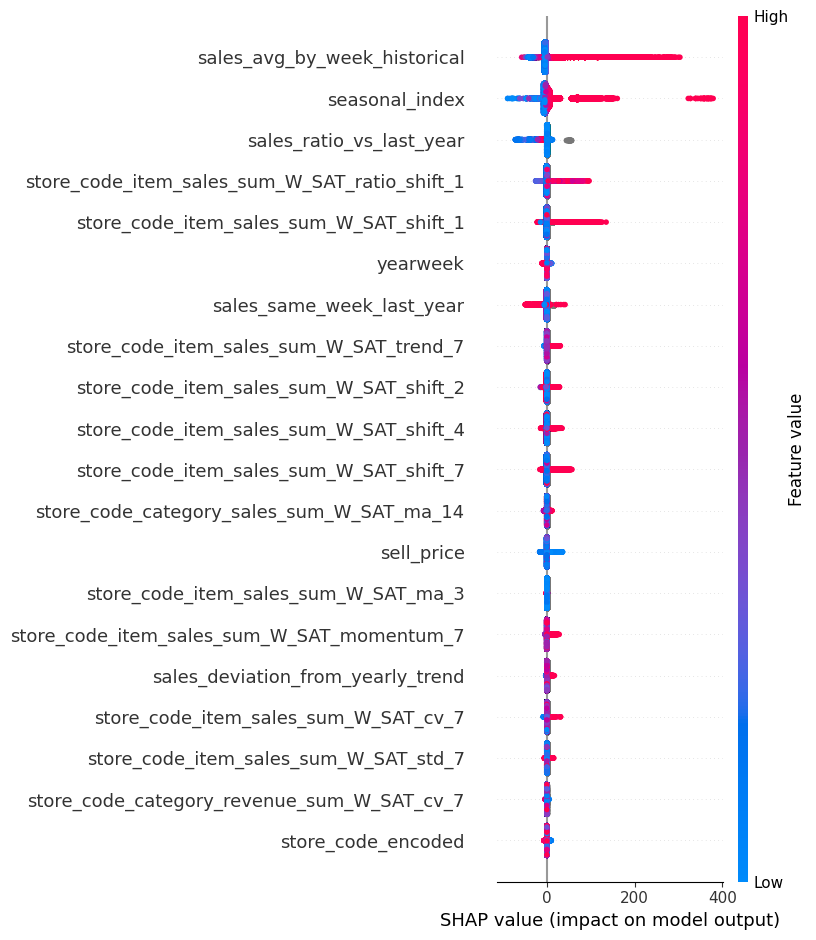

In [ ]:
import shap
# Calcula SHAP
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_train)

# Visualiza
shap.summary_plot(shap_values, X_train)

In [ ]:
# Importancia promedio absoluta de cada feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Crear DataFrame ordenado
shap_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

# Top 5 features
top5_features = shap_importance_df.head(5)
print(top5_features)

                                          feature  importance
4                    sales_avg_by_week_historical        7.20
8                                  seasonal_index        6.32
7                        sales_ratio_vs_last_year        1.57
45  store_code_item_sales_sum_W_SAT_ratio_shift_1        0.35
35        store_code_item_sales_sum_W_SAT_shift_1        0.28


In [ ]:
top5_features_list = top5_features['feature'].tolist()
top5_features_list

['sales_avg_by_week_historical',
 'seasonal_index',
 'sales_ratio_vs_last_year',
 'store_code_item_sales_sum_W_SAT_ratio_shift_1',
 'store_code_item_sales_sum_W_SAT_shift_1']


Train Metrics:
RMSE: 3.2982
Mean Error: -0.0001
R2: 0.9770

Validation Metrics:
RMSE: 3.9773
Mean Error: 0.0183
R2: 0.9659

Test Metrics:
RMSE: 4.7125
Mean Error: -0.0349
R2: 0.9563


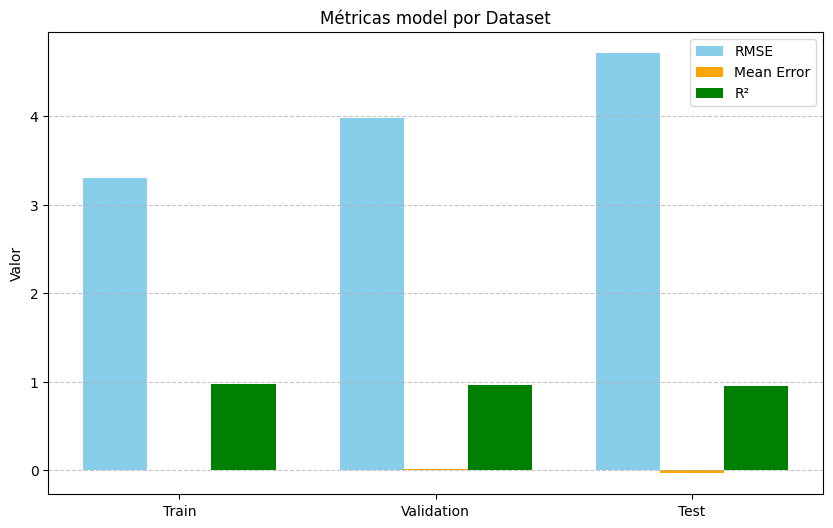

{'Train': {'RMSE': np.float64(3.29820847089436),
  'Mean Error': np.float64(-0.00013834974766372841),
  'R2': 0.9769516951483698},
 'Validation': {'RMSE': np.float64(3.977265700466835),
  'Mean Error': np.float64(0.018347673515483828),
  'R2': 0.9659292669085262},
 'Test': {'RMSE': np.float64(4.712500044149901),
  'Mean Error': np.float64(-0.03494483287695323),
  'R2': 0.9562701254523757}}

In [ ]:
evaluate_model(cat_model, X_train, y_train, X_val, y_val, X_test, y_test)

In [ ]:
y_pred = cat_model.predict(X_pred)

In [ ]:
predicciones_df=df_pred.copy()

In [ ]:
df_predictions_detailed = df[df['date'].isin(prediction_dates)].copy()
df_predictions_detailed = df_predictions_detailed.set_index('id_encoded')
df_predictions_detailed['sales'] = pd.Series(y_pred, index=X_pred.index)
df_predictions_detailed = df_predictions_detailed.reset_index()
df_pred= pd.DataFrame(predicciones_df.groupby('date')['sales'].sum())

df_pred

,sales
date,
2016-03-26,"285,579.61"
2016-04-02,"313,190.15"
2016-04-09,"311,535.69"
2016-04-16,"292,464.26"


In [ ]:
df_ventas_reales

,date,sales
0,2016-03-26,282697
1,2016-04-02,309668
2,2016-04-09,306203
3,2016-04-16,286524


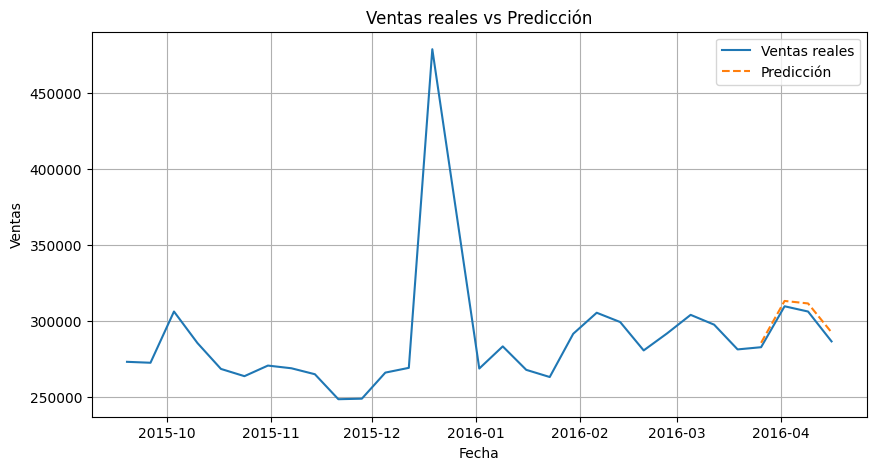

In [ ]:
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred = df_pred.rename(columns={
    col: col.lower() for col in df_pred.columns
})

df_sales_reales = df_sales_reales.rename(columns={"date": "date", "sales": "sales"})
df_pred = df_pred.rename(columns={"fecha": "date", "ventas": "sales"})

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_sales_reales["date"], df_sales_reales["sales"], label="Ventas reales")
plt.plot(df_pred["date"], df_pred["sales"], label="Predicción", linestyle="--")


plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Ventas reales vs Predicción")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


df_predictions_detailed['revenue'] = df_predictions_detailed['sales'] * df_predictions_detailed['sell_price']


df_predictions_detailed = df_predictions_detailed.reset_index()


predicciones_df = df_predictions_detailed.copy()


region_cols = [col for col in predicciones_df.columns if col.startswith('region_')]
if region_cols:
    predicciones_df['region'] = predicciones_df[region_cols].idxmax(axis=1).str.replace('region_', '')

category_cols = [col for col in predicciones_df.columns if col.startswith('category_')]
if category_cols:
    predicciones_df['category'] = predicciones_df[category_cols].idxmax(axis=1).str.replace('category_', '')



ultimas_4_hist = df[
    (df['date'].isin(pd.date_range(end=predicciones_df['date'].max(), periods=4, freq='W-SAT'))) &
    (df['sales'].notna())
]

print("\nÚltimas 4 semanas históricas:")
print(ultimas_4_hist.groupby('date')['sales'].sum())

print("\nPróximas 4 semanas predichas:")
print(predicciones_df.groupby('date')['sales'].sum())


# 4. Ver predicciones por categoría
print("\nPredicciones por categoría (total 4 semanas):")
print(predicciones_df.groupby('category').agg({
    'sales': 'sum',
    'revenue': 'sum'
}).sort_values('sales', ascending=False))

# 5. Top 20 productos con mayores ventas predichas
print("\nTop 20 productos con mayores ventas predichas:")
top_20 = predicciones_df.groupby(['store_code', 'item', 'category']).agg({
    'sales': 'sum',
    'revenue': 'sum'
}).sort_values('sales', ascending=False).head(20)
print(top_20)

# 6. Verificar si hay predicciones negativas o extrañas
print(f"\nPredicciones negativas: {(predicciones_df['sales'] < 0).sum()}")
print(f"Predicciones > 100: {(predicciones_df['sales'] > 100).sum()}")
print(f"Predicciones entre 0-1: {((predicciones_df['sales'] >= 0) & (predicciones_df['sales'] <= 1)).sum()}")

# 7. Comparación semanal promedio
print("\nComparación promedio semanal:")
print(f"Histórico (últimas 4 semanas): {ultimas_4_hist.groupby('date')['sales'].sum().mean():,.0f}")
print(f"Predicción (próximas 4 semanas): {predicciones_df.groupby('date')['sales'].sum().mean():,.0f}")


Últimas 4 semanas históricas:
date
2016-03-26    282697
2016-04-02    309668
2016-04-09    306203
2016-04-16    286524
Name: sales, dtype: int32

Próximas 4 semanas predichas:
date
2016-03-26   285,579.61
2016-04-02   313,190.15
2016-04-09   311,535.69
2016-04-16   292,464.26
Name: sales, dtype: float64

Predicciones por categoría (total 4 semanas):
                   sales      revenue
category                             
SUPERMARKET   799,796.94 2,591,170.00
HOME_&_GARDEN 287,306.81 1,466,888.58
ACCESORIES    115,665.95   682,637.16

Top 20 productos con mayores ventas predichas:
                                            sales   revenue
store_code item              category                      
NYC_3      SUPERMARKET_3_120 SUPERMARKET 1,787.70 10,683.31
BOS_2      SUPERMARKET_3_090 SUPERMARKET 1,751.49  3,152.69
NYC_3      SUPERMARKET_3_090 SUPERMARKET 1,748.80  3,357.69
           SUPERMARKET_3_252 SUPERMARKET 1,736.26  3,291.94
           SUPERMARKET_3_586 SUPERMARKET 1,671.17

In [ ]:
y_future = cat_model.predict(X_future)

In [ ]:
#crear dataset para sale a 4 semanas
last_date = df['date'].max()

id_target = df.groupby('id')['sales'].mean()


features = [
    'sales_avg_by_week_historical',
    'seasonal_index',
    'sales_ratio_vs_last_year',
    'store_code_item_sales_sum_W_SAT_ratio_shift_1',
    'store_code_item_sales_sum_W_SAT_shift_1',
    'yearweek',
    'sales_same_week_last_year',
    'store_code_item_sales_sum_W_SAT_trend_7',
    'store_code_item_sales_sum_W_SAT_shift_2',
    'store_code_item_sales_sum_W_SAT_shift_4',
    'store_code_item_sales_sum_W_SAT_shift_7',
    'store_code_category_sales_sum_W_SAT_ma_14',
    'sell_price',
    'store_code_item_sales_sum_W_SAT_ma_3',
    'store_code_item_sales_sum_W_SAT_momentum_7',
    'sales_deviation_from_yearly_trend',
    'store_code_item_sales_sum_W_SAT_cv_7',
    'store_code_item_sales_sum_W_SAT_std_7',
    'store_code_category_revenue_sum_W_SAT_cv_7',
    'store_code_encoded'
]



future_dates = pd.date_range(start="2016-04-16", periods=4, freq="W-SAT")


def construir_features_para(df, future_dates, X_train_cols, id_target, last_date, X_train_dtypes):

    unique_ids = df['id'].unique()

    future_data_tuples = []
    for f_date in future_dates:
        for u_id in unique_ids:
            future_data_tuples.append((f_date, u_id))
    X_future_full = pd.DataFrame(future_data_tuples, columns=['date', 'id'])

    X_future_full['id_encoded'] = X_future_full['id'].map(id_target)

    last_day_df_static = df[df['date'] == last_date].drop_duplicates(subset=['id']).copy()


    static_per_id_cols = [
        'id', 'item', 'store_code', 'sell_price', 'store_code_encoded', 'item_encoded',
        'region_Boston', 'region_New York', 'region_Philadelphia',
        'category_ACCESORIES', 'category_HOME_&_GARDEN', 'category_SUPERMARKET',
        'event_Easter', 'event_NewYear', 'event_None', 'event_Ramadan starts',
        'event_SuperBowl', 'event_Thanksgiving'
    ]
    static_per_id_cols_present = [col for col in static_per_id_cols if col in last_day_df_static.columns]

    X_future_full = pd.merge(X_future_full, last_day_df_static[static_per_id_cols_present], on='id', how='left')

    X_future_full['yearweek'] = (X_future_full['date'].dt.isocalendar().year.astype(str) +
                                 X_future_full['date'].dt.isocalendar().week.astype(str).str.zfill(2)).astype('int32')
    X_future_full['year'] = X_future_full['date'].dt.isocalendar().year
    X_future_full['week'] = X_future_full['date'].dt.isocalendar().week
    X_future_full['month'] = X_future_full['date'].dt.month
    X_future_full['week_sin'] = np.sin(2 * np.pi * X_future_full['week'] / 52)
    X_future_full['week_cos'] = np.cos(2 * np.pi * X_future_full['week'] / 52)
    X_future_full['month_sin'] = np.sin(2 * np.pi * X_future_full['month'] / 12)
    X_future_full['month_cos'] = np.cos(2 * np.pi * X_future_full['month'] / 12)

    features_to_recalculate = [
        'sales_same_week_last_year', 'sales_ratio_vs_last_year',
        'sales_avg_by_week_historical', 'seasonal_index', 'sales_yearly_trend',
        'sales_deviation_from_yearly_trend'
    ]

    cols_to_exclude_from_propagation = ['id', 'date', 'item', 'store_code', 'id_encoded', 'yearweek', 'year', 'week', 'month',
                                        'week_sin', 'week_cos', 'month_sin', 'month_cos', 'sell_price', 'store_code_encoded', 'item_encoded'] \
                                      + [col for col in X_train_cols if 'region_' in col or 'category_' in col or 'event_' in col]

    features_to_propagate = [col for col in X_train_cols
                             if col not in cols_to_exclude_from_propagation
                             and col not in features_to_recalculate]

    features_to_propagate_existing = [col for col in features_to_propagate if col in df.columns]

    last_known_historical_values_for_merge = df[
        df['date'] == last_date
    ].drop_duplicates(subset=['id'])[features_to_propagate_existing + ['id']].copy()

    X_future_full = pd.merge(
        X_future_full,
        last_known_historical_values_for_merge,
        on='id',
        how='left'
    )


    historical_sales_lookup = df[['date', 'id', 'sales', 'sales_avg_by_week_historical', 'seasonal_index']].copy()
    historical_sales_lookup['date_lagged'] = historical_sales_lookup['date'] + pd.DateOffset(weeks=52)


    historical_sales_lookup_renamed = historical_sales_lookup.rename(columns={
        'sales': 'sales_52_weeks_ago',
        'sales_avg_by_week_historical': 'sales_avg_by_week_historical_52_weeks_ago',
        'seasonal_index': 'seasonal_index_52_weeks_ago'
    })

    X_future_full = pd.merge(
        X_future_full,
        historical_sales_lookup_renamed[['date_lagged', 'id', 'sales_52_weeks_ago', 'sales_avg_by_week_historical_52_weeks_ago', 'seasonal_index_52_weeks_ago']],
        left_on=['date', 'id'],
        right_on=['date_lagged', 'id'],
        how='left' # No suffixes needed now, as column names are already distinct
    )


    X_future_full['sales_same_week_last_year'] = X_future_full['sales_52_weeks_ago'].fillna(0)
    X_future_full['sales_avg_by_week_historical'] = X_future_full['sales_avg_by_week_historical_52_weeks_ago'].fillna(0)
    X_future_full['seasonal_index'] = X_future_full['seasonal_index_52_weeks_ago'].fillna(0)


    X_future_full['sales_ratio_vs_last_year'] = X_future_full['sales_avg_by_week_historical'] / (X_future_full['sales_same_week_last_year'] + 1)
    X_future_full['sales_ratio_vs_last_year'] = X_future_full['sales_ratio_vs_last_year'].replace([np.inf, -np.inf], np.nan).fillna(0) # Handle division by zero



    last_known_trends = df[
        df['date'] == last_date
    ].drop_duplicates(subset=['id'])[['id', 'sales_yearly_trend', 'sales_deviation_from_yearly_trend']].copy()


    last_known_trends_renamed = last_known_trends.rename(columns={
        'sales_yearly_trend': 'sales_yearly_trend_last_known',
        'sales_deviation_from_yearly_trend': 'sales_deviation_from_yearly_trend_last_known'
    })

    X_future_full = pd.merge(
        X_future_full,
        last_known_trends_renamed[['id', 'sales_yearly_trend_last_known', 'sales_deviation_from_yearly_trend_last_known']],
        on='id',
        how='left'
    )
    X_future_full['sales_yearly_trend'] = X_future_full['sales_yearly_trend_last_known'].fillna(0)
    X_future_full['sales_deviation_from_yearly_trend'] = X_future_full['sales_deviation_from_yearly_trend_last_known'].fillna(0)

    X_future_full.drop(columns=[
        'date_lagged',
        'sales_52_weeks_ago',
        'sales_avg_by_week_historical_52_weeks_ago',
        'seasonal_index_52_weeks_ago',
        'sales_yearly_trend_last_known',
        'sales_deviation_from_yearly_trend_last_known'
    ], errors='ignore', inplace=True)


    missing_cols = set(X_train_cols) - set(X_future_full.columns)
    for col in missing_cols:
        X_future_full[col] = 0


    for col in X_train_cols: # Iterate through X_train columns to ensure all expected features are filled
        if col in X_future_full.columns and pd.api.types.is_numeric_dtype(X_future_full[col]):
            X_future_full[col] = X_future_full[col].fillna(0) # Using 0 as a default fill for simplicity


    df_future_mapping = X_future_full[['date', 'id_encoded', 'id', 'item', 'store_code', 'sell_price']].copy()


    X_future = X_future_full.set_index('id_encoded')
    X_future = X_future[X_train_cols].copy()


    for col in X_train_cols:
        if col in X_future.columns:
            expected_dtype = X_train_dtypes[col]
            if expected_dtype == 'bool':
                X_future[col] = X_future[col].astype(bool)
            elif 'float' in str(expected_dtype):
                X_future[col] = X_future[col].astype(float)
                X_future[col] = X_future[col].astype(expected_dtype)
            elif 'int' in str(expected_dtype):

                try:
                    X_future[col] = X_future[col].astype(float).fillna(0).astype(expected_dtype)
                except TypeError:
                    X_future[col] = X_future[col].fillna(0).astype(expected_dtype)

    return X_future, df_future_mapping



last_date = df['date'].max()
X_future, df_future_mapping = construir_features_para(df=df, future_dates=future_dates, X_train_cols=X_train.columns, id_target=id_target, last_date=last_date, X_train_dtypes=X_train.dtypes)



y_future = cat_model.predict(X_future)
y_future_clipped = np.clip(y_future, 0, df['sales'].max() * 1.2)

#
df_future_predictions_detailed = df_future_mapping.copy()
df_future_predictions_detailed['sales'] = y_future_clipped
df_future_predictions_detailed['revenue'] = df_future_predictions_detailed['sales'] * df_future_predictions_detailed['sell_price']


df_pred_fut = df_future_predictions_detailed.groupby('date')['sales'].sum().reset_index()
df_pred_fut.rename(columns={'sales': 'sales_pred'}, inplace=True)

print(df_pred_fut)


        date  sales_pred
0 2016-04-16  311,746.84
1 2016-04-23  315,226.56
2 2016-04-30  337,823.39
3 2016-05-07  325,010.01


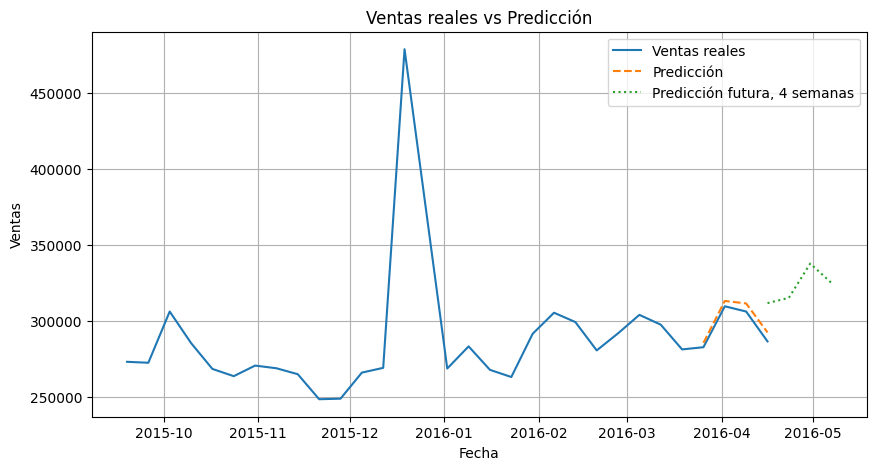

In [ ]:
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred = df_pred.rename(columns={
    col: col.lower() for col in df_pred.columns
})
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred_fut = df_pred_fut.rename(columns={
    col: col.lower() for col in df_pred.columns
})

df_sales_reales = df_sales_reales.rename(columns={"date": "date", "sales": "sales"})
df_pred = df_pred.rename(columns={"fecha": "date", "ventas": "sales"})
df_pred_fut = df_pred_fut.rename(columns={"date": "date", "sales_pred": "sales_pred"})

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_sales_reales["date"], df_sales_reales["sales"], label="Ventas reales")
plt.plot(df_pred["date"], df_pred["sales"], label="Predicción", linestyle="--")
plt.plot(df_pred_fut["date"], df_pred_fut["sales_pred"], label="Predicción futura, 4 semanas", linestyle=":")


plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Ventas reales vs Predicción")
plt.legend()
plt.grid(True)
plt.show()

